In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/churn_data.csv")


df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Basic Data Exploration

In [2]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


Data Cleaning

In [3]:
df.isnull().sum()


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [4]:
df.drop_duplicates(inplace=True)

In [5]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [11]:
# Check if coerced coercion resulted in any null values
print(df["TotalCharges"].isnull().sum())

# Drop those rows (usually a very small percentage of the dataset)
df.dropna(subset=['TotalCharges'], inplace=True)


11


Exploratory Data Analysis (EDA)

Churn Distribution

In [6]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Visualization:

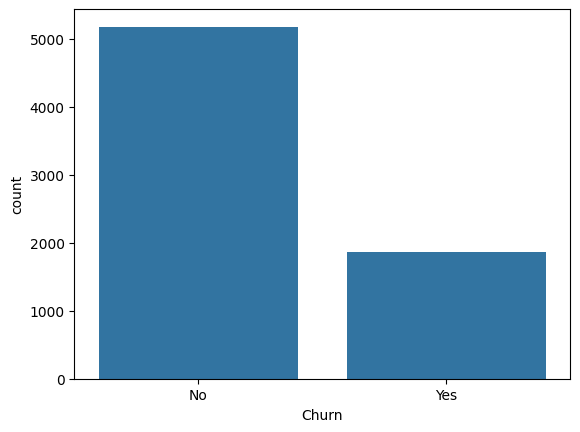

In [7]:
sns.countplot(x="Churn", data=df)
plt.show()

In [ ]:
### Insight from churn distribution chart

- The majority of customers are in the "No" churn category, with a noticeably smaller bar for "Yes".
- This indicates class imbalance: non-churn customers are dominant.
- For modeling, consider stratified splits or class-weighted algorithms.
- For business: prioritize retention efforts on the churn segment and investigate profiles (e.g. Month-to-month, Electronic check) seen in later charts.

Churn by Contract Type


<Axes: xlabel='Contract', ylabel='count'>

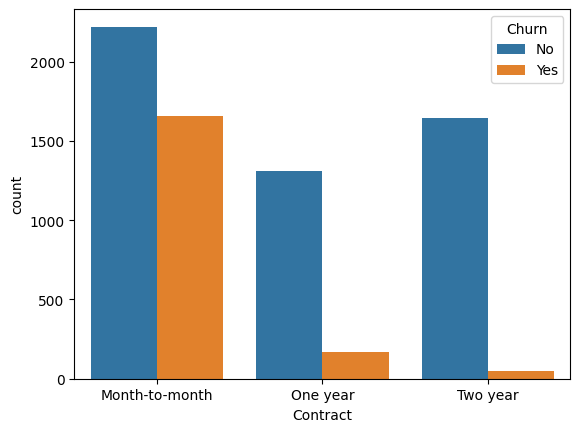

In [8]:
sns.countplot(x="Contract", hue="Churn", data=df)

Churn by Payment Method

([0, 1, 2, 3],
 [Text(0, 0, 'Electronic check'),
  Text(1, 0, 'Mailed check'),
  Text(2, 0, 'Bank transfer (automatic)'),
  Text(3, 0, 'Credit card (automatic)')])

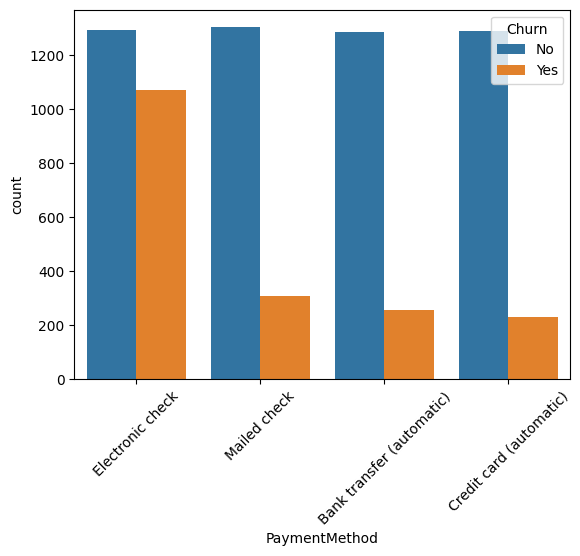

In [9]:
sns.countplot(x="PaymentMethod", hue="Churn", data=df)
plt.xticks(rotation=45)

In [ ]:
### Insight from Monthly Charges vs Churn

- Customers who churn tend to have higher median `MonthlyCharges` than those who do not.
- The `Yes` churn group shows a wider interquartile range and more high-value outliers, suggesting high-cost accounts are more likely to leave.
- The `No` churn group is more concentrated at lower monthly charge levels.
- For retention, target high monthly-charge customers with promotions/discounts, better support, or contract incentives.
- Consider splitting by `InternetService`/`Contract` to see if the pattern is driven by specific service types (e.g., Fiber optic + month-to-month).

Monthly Charges vs Churn

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

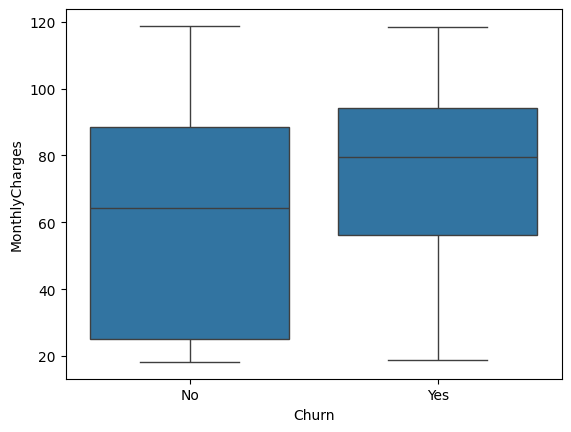

In [10]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)

In [ ]:
### Insight from Monthly Charges vs Churn

- Churn = Yes group has higher median `MonthlyCharges` than Churn = No.
- Churn group shows larger dispersion and more high-value outliers.
- Non-churn is tighter and concentrated at lower charge values.
- Small, clear takeaway: higher monthly spend links to higher churn risk; prioritize retention for these customers.